In [1]:
import numpy as truenp

import matplotlib.pyplot as plt
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    circle,
    spider,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from lina.phase_retrieval import ADPR, FDPR, BBPR
from lina.utils import TikhonovInverse

from psd_utils import PSDUtils

from scipy.optimize import minimize

import stppsf
import config_stp 
import config_stp_wcc

from tqdm import tqdm

%reload_ext autoreload
%autoreload 2
%matplotlib inline

/home/derbyk/miniconda3/envs/py310-stp-env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/home/derbyk/miniconda3/envs/py310-stp-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-25 14:28:06,470	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
print(f'{config_stp.__version__=}')
print(f'{config_stp_wcc.__version__=}')
print(f'{stppsf.__version__=}')

config_stp.__version__='0.0.post102+gf296912'
config_stp_wcc.__version__='0.0.post34+g4ddbba4'
stppsf.__version__='0.1.0'


## Model

Standard model setup except for a couple changes to the source parameters. Currently, FDPR is the best working algorithm for WCC wavefront sensing so the PSF images to be simulated by the model will all be the same on-axis source. We'll assume defocus diversity of 0, 0.25, 0.5, 0.75, and 1 waves of defocus. In effect, this means that we are assuming a single on-axis source at an Rmag of 17 with defocus being introduced by pistoning M2.

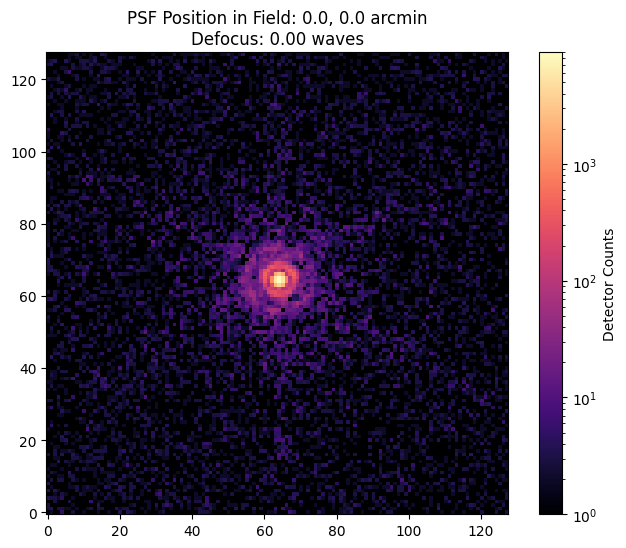

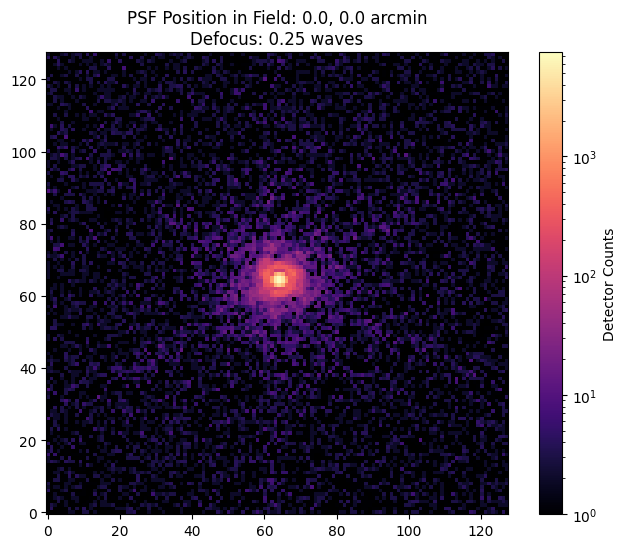

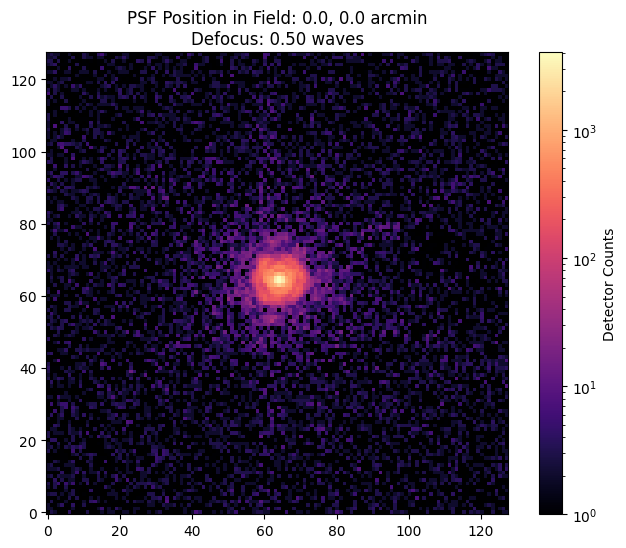

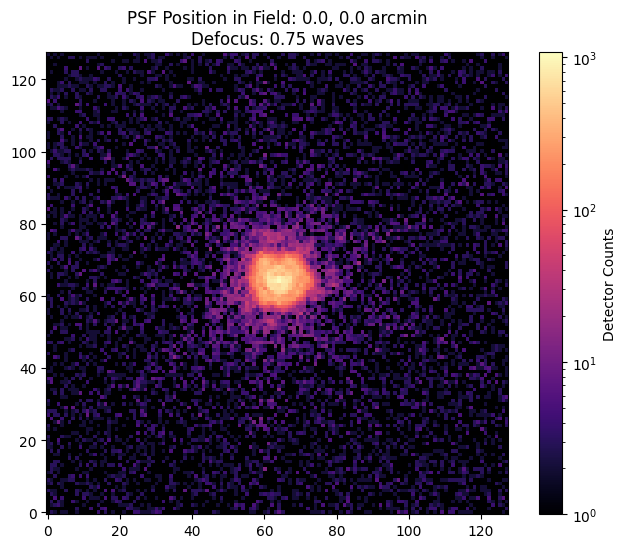

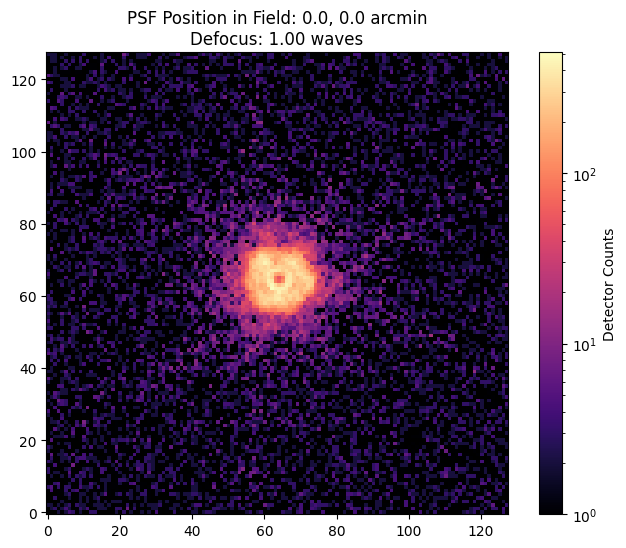

In [3]:
# grab configs
cfg_stp = config_stp.load_config_values('unitless')
cfg_wcc = config_stp_wcc.load_config_values('unitless')

# grab config data paths
path_stp = config_stp.get_data_path()
path_wcc = config_stp_wcc.get_data_path()

# initialize model
sys = stppsf.wcc_fraunhofer.model(config_stp=cfg_stp, config_wcc=cfg_wcc,
                                  data_path_stp=path_stp, data_path_wcc=path_wcc)

# set source parameters
sys.set_source_parameters(magnitudes=[17, 17, 17, 17, 17],
                          positions=[(0, 0), (0, 0), (0, 0), (0, 0), (0, 0)],
                          defocus_vals=[0, 0.25, 0.5, 0.75, 1])

# take PSF images
images = sys.snap()

# and show the PSFs
for i, image in enumerate(images):
    plt.figure(figsize=(8, 6))
    plt.title(f'PSF Position in Field: {sys.src_pos[i][0] * 60:.01f}, {sys.src_pos[i][1] * 60:.01f} arcmin\nDefocus: {sys.defocus_vals[i] / 625:.02f} waves')
    plt.imshow(image.get(), cmap=better_magma, norm='log')
    plt.colorbar(label='Detector Counts')

## M2 Calibration

In the WCC instrument, we control the wavefront using M2 for defocus and coma. Meanwhile, higher-order modes are cleaned up using M1 bending modes. For M2 control, we need to calibrate a jacobian to inverse later. 

In [4]:
# pupil grid for zernike basis
x, y = make_xy_grid(sys.pupil.shape[0], diameter=sys.dx_pup)
r, t = cart_to_polar(x, y)

# zernike basis
nms = [noll_to_nm(i) for i in range(2, 20)]
zernikes = list(zernike_nm_seq(nms, r, t, norm=True))
zernikes = [z / np.max(np.abs(z)) for z in zernikes]

# calibration amplitudes for M2
amp_d = 1e-7        # decenters
amp_t = 0.00011459  # tilts 

# M2 degrees of freedom to calibrate
dofs = ['M2_dx', 'M2_dy', 'M2_dz']

jac_m2 = np.zeros((len(dofs), 5))

# calibration loop
for i, dof in enumerate(dofs):
    response = 0

    if dof.__contains__('d'):
        amps = [-amp_d, amp_d]
    elif dof.__contains__('t'):
        amps = [-amp_t, amp_t]

    for amp in amps:
        sys.move_optics(**{dof : amp})
        opd = sys.get_opds()['Field'][0]        
        opd[~sys.pupil] = np.nan
        sys.move_optics(**{dof : -amp})

        coeffs = lstsq(zernikes, opd)[2:7]
        response += coeffs * amp / (2 * np.var(np.array(amps)))

    jac_m2[i, :] = response

## OPD Timeseries

Loading the Zernike coefficient timeseries generated by Ewan previously. This characterizes how the first 256 Zernikes evolve over 40 hours at 14 second intervals. We only need the first 20 or so for this simulation, beyond that the contributions from higher order Zernikes is negligible.

(0.0, 40.0)

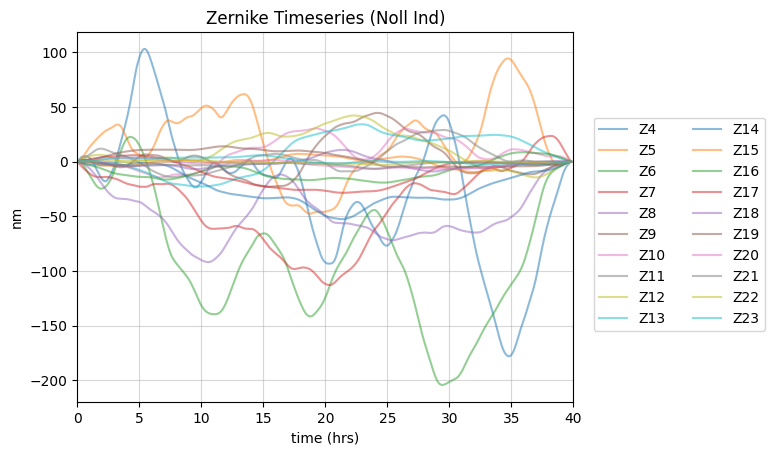

In [5]:
# load timeseries
coeffs_timeseries = fits.getdata('/npool/nvme/derbyk/20240612_wcc_closed_loop/uncorrected_zern_timeseries.fits').T

# time interval
t = np.arange(coeffs_timeseries.shape[0]).get() * 14 # 14 second intervals

# plot timeseries
plt.figure()
for i in range(20):
    plt.plot(t / 3600, coeffs_timeseries[:, i + 3], label='Z' + str(i+3 + 1), alpha=0.5)
plt.title('Zernike Timeseries (Noll Ind)')
plt.xlabel('time (hrs)')
plt.ylabel('nm')
plt.legend(ncols=2, loc='center right', bbox_to_anchor=(1.4, 0.48))
plt.grid(True, which='both', alpha=0.5)
plt.xlim([0, 40])


## FDPR

Now let's set up the FDPR optimizer. We first set up individual ADPR optimizers for each PSF, then give those to FDPR.

In [6]:
# create ADPR optimizers
defocus_coeffs = [0, 0.25, 0.5, 0.75, 1]
adpr_list = []
for psf, defocus_coeff in zip(images, defocus_coeffs):
    adpr_list.append(ADPR(wvls=sys.wvls.tolist(), pupil=sys.pupil, dx_pupil=sys.dx_pup, psf=psf, dx_psf=sys.dx_detector,
                          efl=sys.efl, modes=np.array(zernikes), defocus_coeff=defocus_coeff))
    
# use those to create FDPR optimizer
fdpr = FDPR(optlist=adpr_list)

## Closed-Loop Control

With the model and FDPR set up, we can now perform closed-loop control. This script will introduce wavefront error from the Zernike timeseries through the model's `.add_m1_bending()` method, then simulate a set of PSF images for FDPR. FDPR then estimates the wavefront error and a corrections are fed to M1 and M2. The results are stored in a list for later analysis. The 14 second interval of the timeseries happens to match the time it takes FDPR to run quite well, so I'm not going to interpolate intermediate values. This means that this loop is running at ~0.07 Hz.

Also, since this is a demo we'll just run 100 iterations of closed-loop control.

In [7]:
# M2 control matrix
control_m2 = TikhonovInverse(jac_m2, rcond=1e-2)

# make sure M1 bending is reset to zeros
sys.set_m1_bending(np.zeros((sys.npix, sys.npix)))

# make sure M2 position is reset
sys.reset_optics()

# gain settings
gain_m1 = 0.75
gain_m2 = 0.25

# results to store for analysis
opd_estimates = []
opd_truths = []
obs_images = []

# loop over first 100 points in timeseries
for i, coeffs in enumerate(coeffs_timeseries[:100]):

    # create wavefront error from timeseries coefficients and add to system
    opd_error = sum_of_2d_modes(np.array(zernikes[2:]), np.array(coeffs[3:19]))
    sys.add_m1_bending(opd_error)

    # take images for FDPR
    images = sys.snap()
    obs_images.append(images)

    # update FDPR and run optimizer
    for image, adpr in zip(images, adpr_list):
        adpr.psf = image

    result = minimize(fdpr.fg, x0=np.zeros(len(zernikes)).get(), jac=True, method='L-BFGS-B',
                      options={'maxls': 20, 'ftol': 1e-20, 'gtol': 1e-8, 'disp': 0, 'maxiter':50})

    # get the known system OPDs for ground truth
    sys_opds = sys.get_opds()
    truth = np.sum(np.array(sys_opds['Optics']), axis=0) + sys_opds['Bending'] + sys_opds['Field'][0]
    opd_truths.append(truth)

    # get the estimated OPDs
    estimate = sum_of_2d_modes(np.array(zernikes), np.array(result.x)) 
    opd_estimates.append(estimate)

    # wavefront correction
    # defocus and coma with M2
    command_m2 = np.matmul(control_m2.T, np.array(result.x[2:7])).get()
    sys.move_optics(**{'M2_dx' : -command_m2[0] * gain_m2,
                       'M2_dy' : -command_m2[1] * gain_m2,
                       'M2_dz' : -command_m2[2] * gain_m2,})

    # astig and higher-orders with M1
    sys.add_m1_bending(-sum_of_2d_modes(np.array(zernikes[:2]), np.array(result.x[:2])) * gain_m1)
    sys.add_m1_bending(-sum_of_2d_modes(np.array(zernikes[3:5]), np.array(result.x[3:5])) * gain_m1)
    sys.add_m1_bending(-sum_of_2d_modes(np.array(zernikes[7:]), np.array(result.x[7:])) * gain_m1)

    print(f'Iteration {i + 1:.0f}: {np.sqrt(np.mean(truth[sys.pupil] ** 2)):.2f} nm RMS OPD', end='\r')
    


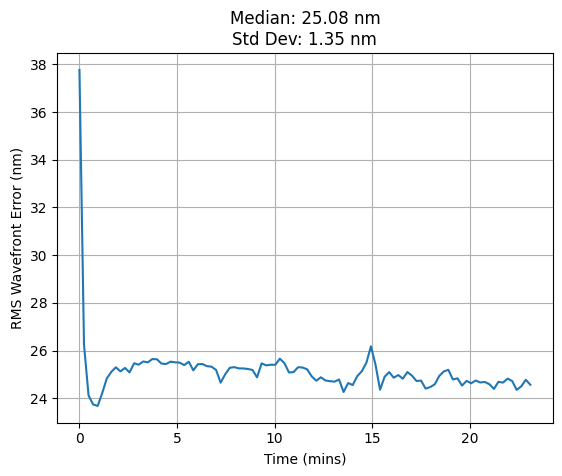

In [8]:
rms_vals = np.array([np.sqrt(np.mean(truth[sys.pupil] ** 2)) for truth in opd_truths])
t = np.arange(len(rms_vals)) * 14 

plt.plot(t.get() / 60, rms_vals.get())
plt.title(f'Median: {np.median(rms_vals):.2f} nm\nStd Dev: {np.std(rms_vals):.2f} nm')
plt.xlabel('Time (mins)')
plt.ylabel('RMS Wavefront Error (nm)')
plt.grid()

The median RMS wavefront error is 25.08 nm under closed-loop control using FDPR for wavefront sensing, M2 bulk motion for defocus/coma correction, and M1 bending for astig/high-order correction. Additionally, the standard deviation of RMS wavefront error is 1.35 nm under closed-loop control. 